In [1]:
import math

In [2]:
from math import*

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
#import polars as pl

In [6]:
import pyarrow.parquet as pq

In [7]:
import matplotlib.pyplot as plt

In [8]:
def delta_p_df(df):
    return df.diff(axis=1).iloc[:, 1:]

In [9]:
def convert_to_matrix(subset_data):
    return subset_data.to_numpy()

In [10]:
def covariance_to_correlation(cov_matrix):
    variances = np.diag(cov_matrix)
    std_deviations = np.sqrt(variances)
    std_outer = np.outer(std_deviations, std_deviations)
    correlation_matrix = cov_matrix/std_outer
    return correlation_matrix

In [11]:
def split_column_name(col_name):
    parts = [int(x) for x in col_name.split("_")]
    return (parts[2],parts[1],parts[0])

def subset_site_cols_organized(dataframe, location):
    '''takes in dataframe as a table and a location number as a string and returns the subset'''
    cols_selected = [
        col for col in dataframe.columns
        if col == "1_0_1" or col.split("_")[0] == location
    ]
    subset_site = dataframe[cols_selected]

    sorted_columns = sorted(subset_site.columns, key=split_column_name)
    subset_site_organized = subset_site[sorted_columns]
    
    return subset_site_organized

In [12]:
seedmix = pd.read_csv("seedmix_hapfire_allele_frequency_random_switch_fixrm.csv", nrows=5000)

In [13]:
master_df = pd.read_csv("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.csv", nrows=5000)

In [14]:
master_df.insert(loc=0, column="1_0_1", value = seedmix["X3"])

In [15]:
full_seedmix = pd.read_csv("seedmix_hapfire_allele_frequency_random_switch_fixrm.csv", usecols=['X3'])

In [16]:
#lazy_df = pl.scan_csv("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.csv", null_values='NA').sink_parquet('output.parquet', compression='zstd')

In [17]:
def lazy_load(file_path, df_master, location, replicate):
    '''lazy load the columns needed'''

    if replicate == 'None':
        cols_selected = [
            col for col in df_master.columns
            if col != '1_0_1' and col.split("_")[0] == location
        ]

    else:
    
        cols_selected = [
            col for col in df_master.columns
            if col != '1_0_1' and col.split("_")[0] == location and col.split("_")[-1] == replicate
        ]

    cols_sorted = sorted(cols_selected, key=split_column_name)

    df = pd.read_parquet(file_path, columns=cols_sorted)
    
    df.insert(0, '1_0_1', full_seedmix['X3'])
    
    return df

In [18]:
#lazy_load("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57', 'None').cov()

In [19]:
def array_the_reps(master_matrix_df):
    return sorted(list(set(int(col.split('_')[2]) for col in master_matrix_df.columns)))

In [20]:
def array_the_gens(master_matrix_df):
    return sorted(list(set(int(col.split('_')[1]) for col in master_matrix_df.columns)))

In [21]:
sites = sorted(list(set(int(col.split('_')[0]) for col in master_df.columns)))

In [39]:
def delta_p_all_reps_at_site(site):
    rep_list = array_the_reps(subset_site_cols_organized(master_df, site))
    delta_p_list = []
    for r in rep_list:
        rep_df = subset_site_cols_organized(lazy_load("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, site, str(r)), site)
        delta_p = delta_p_df(rep_df)
        delta_p_list.append(delta_p)

    combined_delta_p = pd.concat(delta_p_list, axis=1)

    return combined_delta_p

In [23]:
# Creates new dataframe built by the delta_p per replicate at a site, computes the covariance

#def delta_p_all_reps_at_site(site, lazy_flag = False):
  #  rep_list = array_the_reps(subset_site_cols_organized(master_df, site))

  #  if lazy_flag:
  #      delta_p_list = []
   #     for r in rep_list:
    #        rep_df = subset_site_cols_organized(lazy_load("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, site, str(r)), site)
     #       delta_p = delta_p_df(rep_df)
      #      delta_p_list.append(delta_p)

       # combined_delta_p = pd.concat(delta_p_list, axis=1, join='inner')
   # else:
    #    delta_p_list = []
     #   for r in rep_list:
      #      rep_df = subset_site_cols_organized(master_df, site) #fix to loop through r
   # return combined_delta_p

In [24]:
from itertools import combinations

def convergent_correlation(cov_for_all_reps, generations, replicates):
    labels = [f'Gen_{g}' for g in generations]
    conv_corr_matrix = pd.DataFrame(np.nan, index = labels, columns = labels)

    columns_map = {}
    for col in cov_for_all_reps.columns:
        parts = col.split("_")
        if len(parts)>=3:
            columns_map[(str(parts[1]), str(parts[2]))] = col
    
    reps_str = [str(r) for r in replicates]

    for i, g1 in enumerate(generations):
        for g2 in generations[i:]:
            s, t = str(g1), str(g2)
            pair_correlations = []

            if s==t:
                rep_pairs = [(r,r) for r in reps_str]

            else:
                rep_pairs = list(combinations(reps_str, 2))

            for rep_A, rep_B in rep_pairs:
                col_s_A = columns_map.get((s, rep_A))
                col_t_B = columns_map.get((t, rep_B))
                col_s_B = columns_map.get((s, rep_B))
                col_t_A = columns_map.get((t, rep_A))

                if not (col_s_A and col_t_B and col_s_B and col_t_A):
                    continue

                cov_1 = cov_for_all_reps.loc[col_s_A, col_t_B]
                var_s_A = cov_for_all_reps.loc[col_s_A, col_s_A]
                var_t_B = cov_for_all_reps.loc[col_t_B, col_t_B]

                cov_2 = cov_for_all_reps.loc[col_t_A, col_s_B]
                var_t_A = cov_for_all_reps.loc[col_t_A, col_t_A]
                var_s_B = cov_for_all_reps.loc[col_s_B, col_s_B]

                denom1 = np.sqrt(var_s_A*var_t_B)
                denom2 = np.sqrt(var_t_A*var_s_B)

                if denom1>0 and denom2>0:
                    corr1 = cov_1/denom1
                    corr2 = cov_2/denom2
                    pair_correlations.append((corr1+corr2)/2.0)

            val = np.nanmean(pair_correlations) if pair_correlations else np.nan
            conv_corr_matrix.loc[f"Gen_{s}", f"Gen_{t}"] = val
            conv_corr_matrix.loc[f"Gen_{t}", f"Gen_{s}"] = val

    return conv_corr_matrix

In [36]:
from itertools import product

def between_sites(site1, site2, gens1, gens2, reps1, reps2, site1_id, site2_id):

    gens = sorted(list(set(gens1) & set(gens2)))
    
    reps_1 = [str(r) for r in reps1]
    reps_2 = [str(r) for r in reps2]

    correlations_through_time = {}
    for g in gens:
        str_g = str(g)
        cols_site1 = [col for col in site1.columns if col.split("_")[1] == str_g]
        cols_site2 = [col for col in site2.columns if col.split("_")[1] == str_g]

        site1_time_g = site1[cols_site1]
        site2_time_g = site2[cols_site2]

        cov_sites_time_g = pd.concat([site1_time_g, site2_time_g], axis = 1).cov()

        columns_map = {}
        for col in cov_sites_time_g.columns:
            parts = col.split("_")
            if len(parts)>=3:
                columns_map[(str(parts[0]), str(parts[2]))] = col
        
        rep_pairs = list(product(reps_1, reps_2))

        s1, s2 = str(site1_id), str(site2_id)
        
        correlations = []
        for rep1, rep2 in rep_pairs:
            cols_s1_rep1 = columns_map.get((s1, rep1))
            cols_s2_rep2 = columns_map.get((s2, rep2))

            if not (cols_s1_rep1 and cols_s2_rep2):
                continue 

            cov = cov_sites_time_g.loc[cols_s1_rep1, cols_s2_rep2]
            var_s1_rep1 = cov_sites_time_g.loc[cols_s1_rep1, cols_s1_rep1]
            var_s2_rep2 = cov_sites_time_g.loc[cols_s2_rep2, cols_s2_rep2]

            denom = np.sqrt(var_s1_rep1*var_s2_rep2)
            if denom>0:
                corr = cov/denom

                correlations.append(corr)

        val = np.nanmean(correlations) if correlations else np.nan
        
        correlations_through_time[g] = val

    return pd.Series(correlations_through_time)

In [26]:
def get_site_cols(dataframe, site):
    str_site = str(site)
    cols_selected = [col for col in dataframe.columns if col != '1_0_1' and col.split("_")[0] == str_site
        ]
    return dataframe[cols_selected]

In [ ]:
# don't run

import pickle
import gzip

sites = sorted(list(set(int(col.split('_')[0]) for col in master_df.columns)))
site_matrices = {}
for site in sites:
    site_str = str(site)
    site_matrices[site_str] = delta_p_all_reps_at_site(site_str)
    print(f"Finished site {site_str}")

with gzip.open("site_matrices.pkl.gz", "wb", compresslevel=1) as f:
    pickle.dump(site_matrices, f, protocol = pickle.HIGHEST_PROTOCOL)

In [27]:
# future pickle

import pickle
import gzip

with gzip.open("site_matrices.pkl.gz", "rb") as f:
    site_matrices_loaded = pickle.load(f)

In [28]:
def between_sites_values(sites, main_site, year_of_int):
    year_of_interest_values = {}
    main_site_str = str(main_site)
    main_site_matrix = site_matrices_loaded[main_site_str]
    main_site_gens = array_the_gens(get_site_cols(master_df, main_site_str))
    main_site_reps = array_the_reps(get_site_cols(master_df, main_site_str))
    
    for site in sites:
        site_str = str(site)
        if site_str != main_site_str:
            site_comparison = site_matrices_loaded[site_str]
            site_comp_gens = array_the_gens(get_site_cols(master_df, site_str))
            site_comp_reps = array_the_reps(get_site_cols(master_df, site_str))
            resulting_series = between_sites(main_site_matrix, site_comparison, main_site_gens, site_comp_gens, main_site_reps, site_comp_reps, main_site, str(site))
            if year_of_int in resulting_series.index:
                year_of_interest_values[site] = resulting_series.loc[year_of_int]
            else:
                continue
    return pd.Series(year_of_interest_values, name='convergence_correlation')

In [ ]:
# create df of all site comparisons and year comparisons. Be able to select a site compared across all sites and a year.
import pathlib

between_sites_convergences = pathlib.Path("between_sites_conv_corr.csv")
rows = []
for i, site1 in enumerate(sites[:-1]):
    str_site1 = str(site1)
    main_site = site_matrices_loaded[str_site1]
    main_site_gens = array_the_gens(get_site_cols(master_df, str_site1))
    main_site_reps = array_the_reps(get_site_cols(master_df, str_site1))
    for site2 in sites[i+1 :]:
        str_site2 = str(site2)
        site_matrix = site_matrices_loaded[str_site2]
        site_gens = array_the_gens(get_site_cols(master_df, str_site2))
        site_reps = array_the_reps(get_site_cols(master_df, str_site2))

        res_series = between_sites(main_site, site_matrix, main_site_gens, site_gens, main_site_reps, site_reps, str_site1, str_site2)
        for year, corr_val in res_series.items():
            rows.append({"main_site": str(site1), "other_site": str(site2), "year": year, "convergence_correlation": corr_val})
            print(f"Finished site {str_site1, str_site2}, year {year}")
            between_sites_convergences_df = pd.DataFrame(rows)
            between_sites_convergences_df.to_csv("between_sites_conv_corr.csv", index=False, mode='a', header=not between_sites_convergences.exists())

Finished site ('1', '2'), year 1
Finished site ('1', '2'), year 2
Finished site ('1', '2'), year 4
Finished site ('1', '4'), year 1
Finished site ('1', '4'), year 2
Finished site ('1', '4'), year 3
Finished site ('1', '5'), year 1
Finished site ('1', '5'), year 2
Finished site ('1', '5'), year 3
Finished site ('1', '6'), year 1
Finished site ('1', '6'), year 2
Finished site ('1', '9'), year 1
Finished site ('1', '9'), year 2
Finished site ('1', '9'), year 3
Finished site ('1', '10'), year 1
Finished site ('1', '10'), year 2
Finished site ('1', '10'), year 3
Finished site ('1', '11'), year 1
Finished site ('1', '11'), year 2
Finished site ('1', '11'), year 3
Finished site ('1', '12'), year 1
Finished site ('1', '12'), year 2
Finished site ('1', '13'), year 1
Finished site ('1', '13'), year 2
Finished site ('1', '13'), year 3
Finished site ('1', '23'), year 1
Finished site ('1', '24'), year 1
Finished site ('1', '24'), year 2
Finished site ('1', '25'), year 1
Finished site ('1', '25'), y

In [29]:
between_sites_values(sites, '57', 1)

1     0.174442
2     0.151679
4     0.013809
5     0.000119
6     0.079632
9     0.239209
10    0.172930
11    0.106457
12    0.102636
13    0.124785
23   -0.016355
24    0.116422
25    0.101079
26    0.025938
27    0.010708
28    0.146827
32   -0.111577
33    0.029878
37    0.175790
42    0.089526
43   -0.047883
45    0.216773
46    0.150028
48   -0.009793
49    0.054705
52    0.078342
53    0.052893
54   -0.002746
55    0.002803
60    0.004619
Name: convergence_correlation, dtype: float64

In [33]:
# create a table where site X variables are compared to all other site variables

bio_table = pd.read_csv("bioclimvars_experimental_sites_era5.csv")
bio_table['site'] = bio_table['site'].astype(str)

def pair_diff(bio_table, target_site, bio_var):
    '''target_site and bio_var as strings'''
    ref_val = bio_table.loc[bio_table['site']==target_site, bio_var].values[0]
    other_sites_df = bio_table[bio_table['site'] != target_site].copy()
    other_sites_df['diff'] = (other_sites_df[bio_var] - ref_val).abs()
    other_sites_df['site comparison'] = target_site + "-" + other_sites_df['site']
    result = other_sites_df[['site comparison', 'site', 'diff']].reset_index(drop=True)
    return result

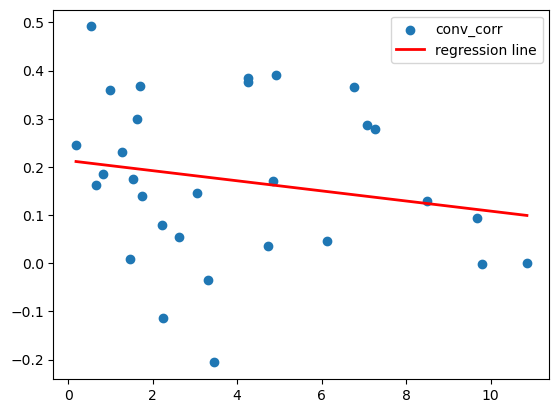

-0.01049130001489836


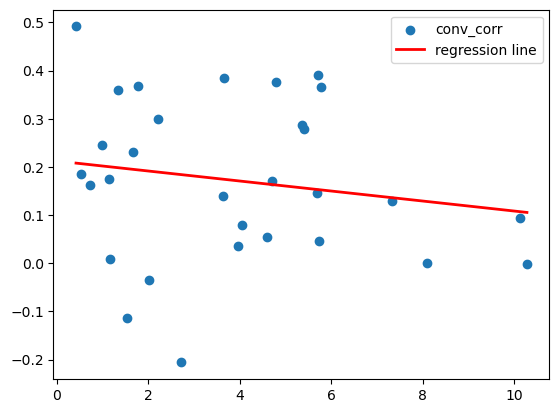

-0.010384151533925341


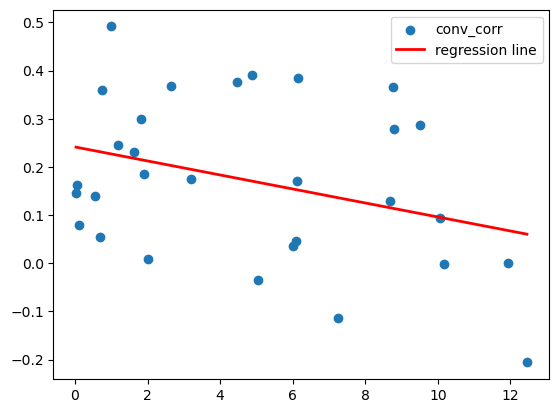

-0.014534390628428335


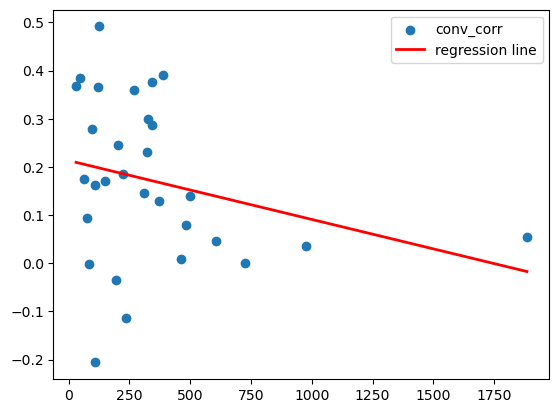

-0.00012221618390637355


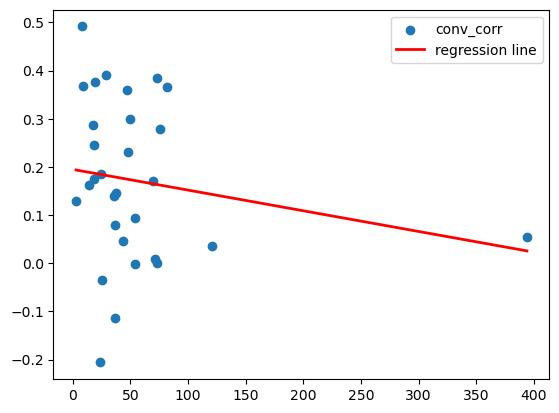

-0.00042958389723032843


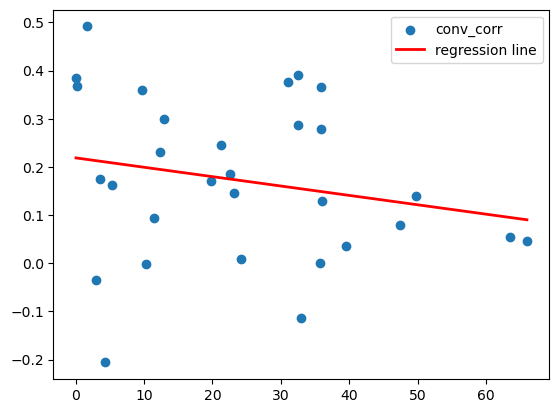

-0.0019492447101792474


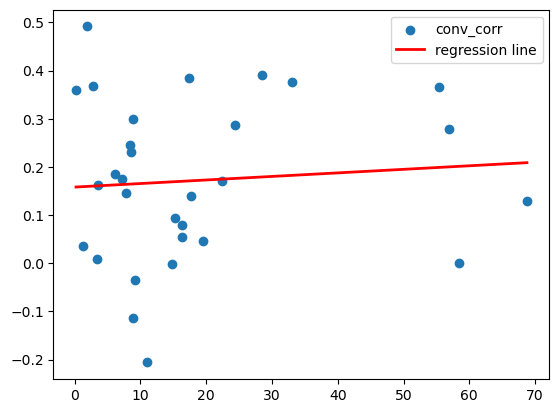

0.0007374835773457867


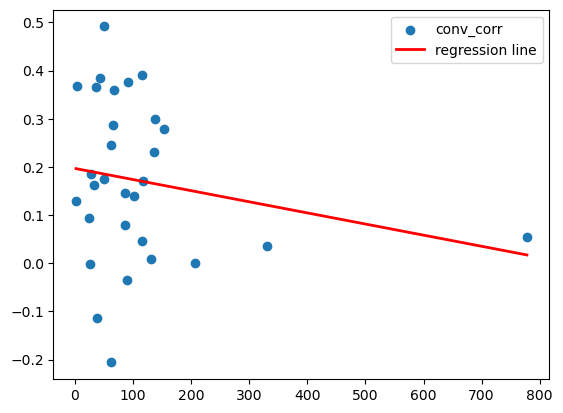

-0.0002308957032954248


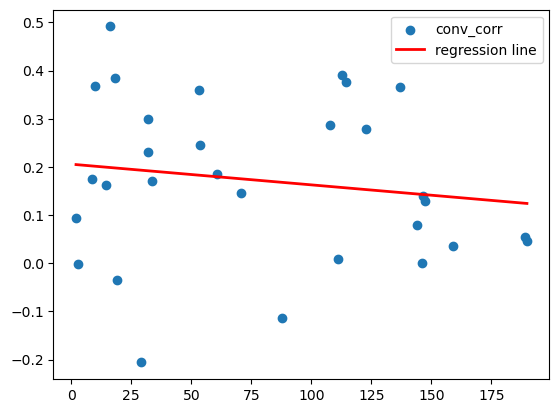

-0.0004296560077089055


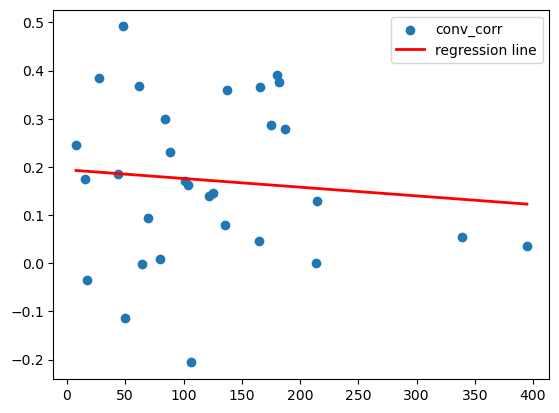

-0.0001804796936146892


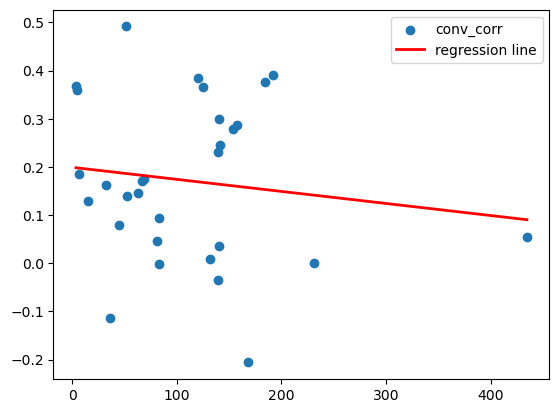

-0.00025006184338689596


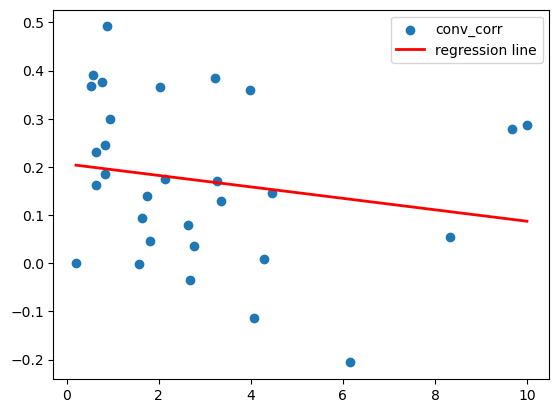

-0.011885014227391077


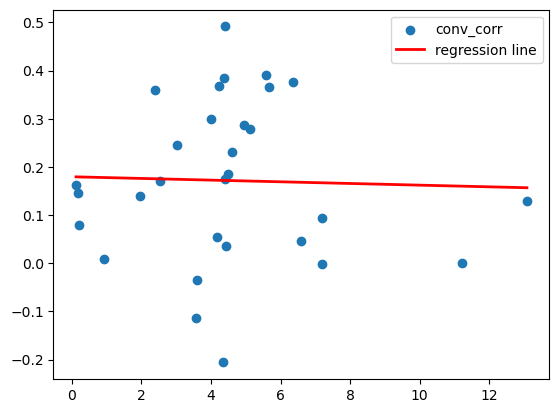

-0.0017419494886906836


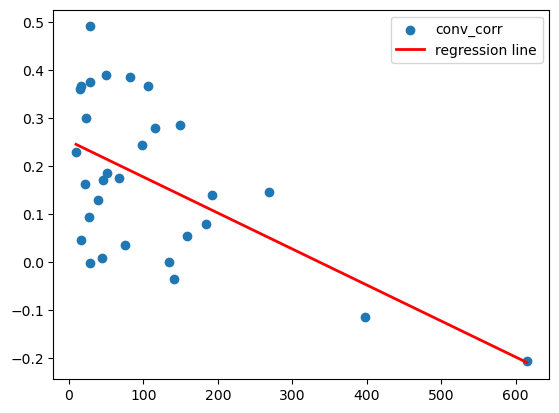

-0.000751680134466674


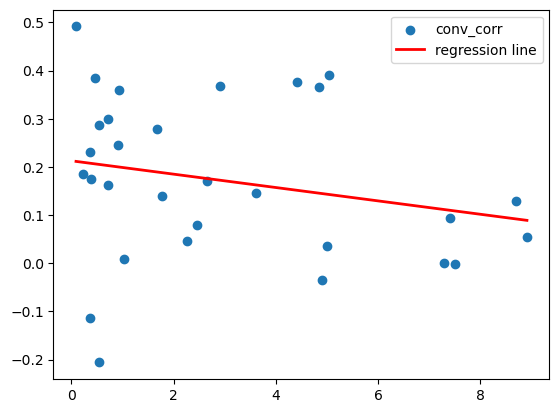

-0.013875519095517251


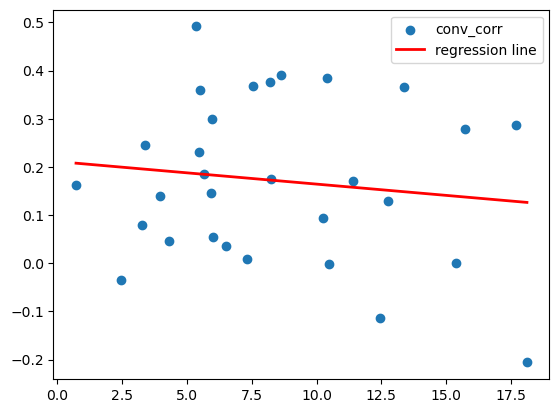

-0.004682228300994452


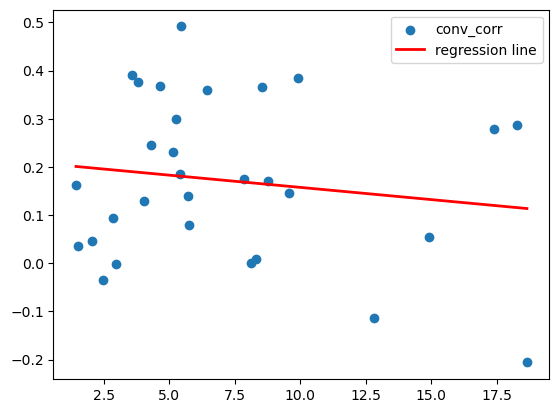

-0.005073298515542622


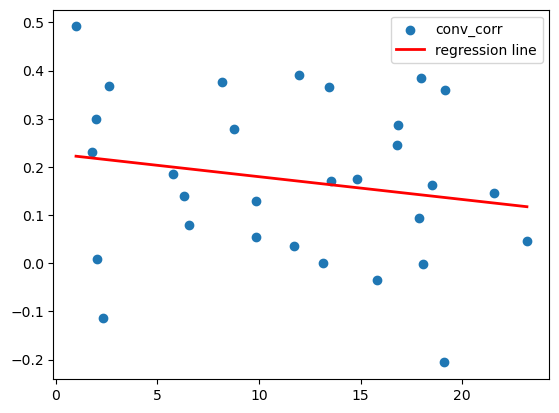

-0.0047274665477490116


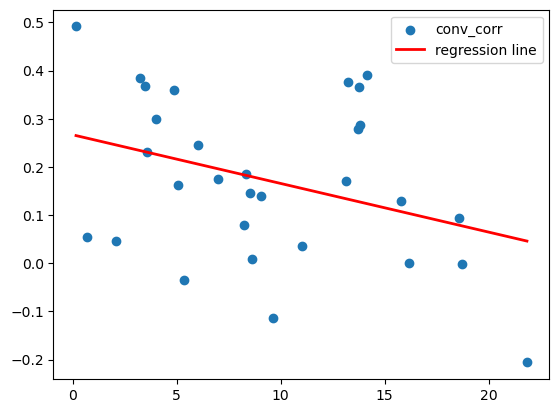

-0.010110287029605196


In [36]:
bio_vars_list = sorted(list(set(col for col in bio_table.columns if col != 'site')))
site_1_comparisons.index = site_1_comparisons.index.astype(str)
%matplotlib inline

for var in bio_vars_list:
    pair_diff_vars_w_site1 = pair_diff(bio_table, '1', var).sort_values(by='diff')
    bio_table_with_corr = pd.merge(pair_diff_vars_w_site1, site_1_comparisons, left_on='site', right_index = True, how = "left")
    bio_table_with_corr.dropna(inplace=True)
    x = bio_table_with_corr['diff']
    y = bio_table_with_corr['convergence_correlation']
    plt.scatter(x,y,label='conv_corr')
    m, b = np.polyfit(x,y, deg=1)
    plt.plot(x, m*x+b, color='red', linewidth = 2, label = 'regression line')
    plt.legend()
    plt.show()
    print(m)

In [27]:
cov_for_site_57 = delta_p_all_reps_at_site('57').cov()
gens = array_the_gens(cov_for_site_57)
reps = array_the_reps(cov_for_site_57)
convergent_correlation(cov_for_site_57, gens, reps) 

,Gen_1,Gen_2,Gen_3,Gen_4,Gen_5
Gen_1,1.000000,-0.094335,0.069528,-0.048028,0.029680
Gen_2,-0.094335,1.000000,-0.071390,0.024486,0.042071
Gen_3,0.069528,-0.071390,1.000000,-0.048005,-0.064537
Gen_4,-0.048028,0.024486,-0.048005,1.000000,-0.078295
Gen_5,0.029680,0.042071,-0.064537,-0.078295,1.000000


In [26]:
site_27 = delta_p_all_reps_at_site('27')
site_57 = delta_p_all_reps_at_site('57')
gens_27 = array_the_gens(site_27)
gens_57 = array_the_gens(site_57)
reps_27 = array_the_reps(site_27)
reps_57 = array_the_reps(site_57)
between_sites(site_27, site_57, gens_27, gens_57, reps_27, reps_57, '27', '57').loc[1]

0.010707630520566747

In [25]:
site_27 = delta_p_all_reps_at_site('1')
site_57 = delta_p_all_reps_at_site('57')
gens_27 = array_the_gens(site_27)
gens_57 = array_the_gens(site_57)
reps_27 = array_the_reps(site_27)
reps_57 = array_the_reps(site_57)
between_sites(site_27, site_57, gens_27, gens_57, reps_27, reps_57, '1', '57')

1    0.174442
2    0.032565
3    0.034869
4    0.015451
dtype: float64

In [28]:
site_1_comparisons = between_sites_values(sites, '1', 1)

In [33]:
site_1_comparisons.index = site_1_comparisons.index.astype(str)
site_1_bio_table = pair_diff(bio_table, '1', 'bio1').sort_values(by='diff')
bio_table_with_corr = pd.merge(site_1_bio_table, site_1_comparisons, left_on='site', right_index = True, how = "left")
bio_table_with_corr

,site comparison,site,diff,convergence_correlation
18,1-35,35,0.049137,NaN
22,1-42,42,0.183145,0.244781
21,1-41,41,0.239742,NaN
41,1-7,7,0.349039,NaN
25,1-46,46,0.533121,0.491658
10,1-25,25,0.649609,0.162707
7,1-21,21,0.790113,NaN
35,1-55,55,0.820596,0.186290
28,1-49,49,0.977375,0.360412
15,1-30,30,1.058265,NaN


In [41]:
site_1_comparisons.index = site_1_comparisons.index.astype(str)
site_1_bio2_table = pair_diff(bio_table, '1', 'bio2').sort_values(by='diff')
bio2_table_with_corr = pd.merge(site_1_bio2_table, site_1_comparisons, left_on='site', right_index = True, how = "left")
bio2_table_with_corr

,site comparison,site,diff,convergence_correlation
41,1-7,7,0.025296,NaN
21,1-41,41,0.146966,NaN
11,1-26,26,0.202694,0.000017
34,1-54,54,0.527318,0.367692
24,1-45,45,0.579611,0.390549
10,1-25,25,0.629840,0.162707
32,1-52,52,0.634851,0.230280
29,1-5,5,0.775020,0.376070
35,1-55,55,0.824563,0.186290
22,1-42,42,0.828691,0.244781


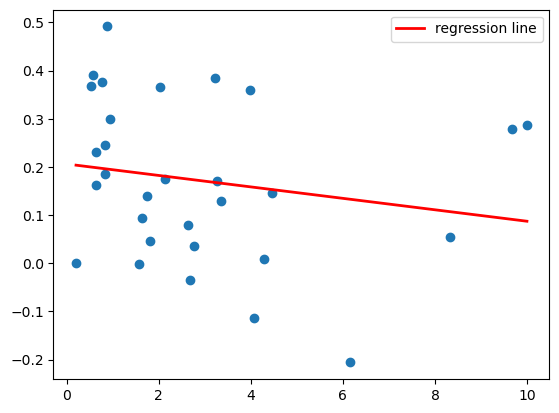

-0.011885014227391077

In [45]:
%matplotlib inline
bio2_table_with_corr.dropna(inplace=True)
s = bio2_table_with_corr['diff']
t = bio2_table_with_corr['convergence_correlation']
#bio_table_with_corr.plot(x = "diff", y = "convergence_correlation", kind = "scatter")
plt.scatter(s,t)
m, b = np.polyfit(s,t, deg=1)
plt.plot(s, m*s+b, color='red', linewidth = 2, label = 'regression line')
plt.legend()
plt.show()
m

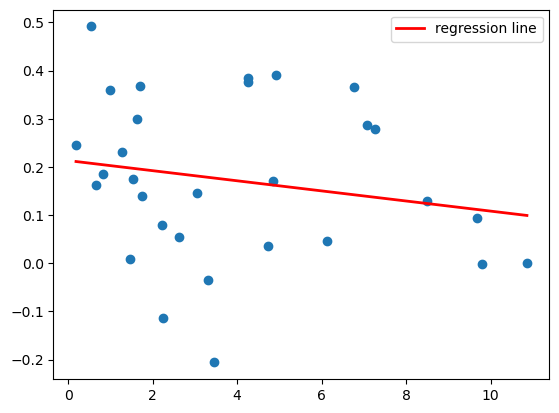

-0.01049130001489836

In [46]:
%matplotlib inline
bio_table_with_corr.dropna(inplace=True)
x = bio_table_with_corr['diff']
y = bio_table_with_corr['convergence_correlation']
#bio_table_with_corr.plot(x = "diff", y = "convergence_correlation", kind = "scatter")
plt.scatter(x,y)
slope, intercept = np.polyfit(x,y, deg=1)
plt.plot(x, slope*x+intercept, color='red', linewidth = 2, label = 'regression line')
plt.legend()
plt.show()
slope

In [ ]:
not_sites = [x for x in site_1_bio_table["site"] if x not in str(sites)]
print(not_sites)

In [43]:
sites

[1,
 2,
 4,
 5,
 6,
 9,
 10,
 11,
 12,
 13,
 23,
 24,
 25,
 26,
 27,
 28,
 32,
 33,
 37,
 42,
 43,
 45,
 46,
 48,
 49,
 52,
 53,
 54,
 55,
 57,
 60]

In [33]:
# bio variables
# idea: be able to grab a column of biovariable differences to become the x-axis for correlation plot
# idea: map out the bio diffs to the sites being compared
# two for loops: iterate from the first position to position n-1, second for loop iterate from i+1 to n
# def pair_diff(X): where X is a column (vector of numbers), 
# two for loops: for i in range(len(x)-1) for j in range(i:len(x)) --> x[i] - x[j]
# abs or square differences
# show which two sites were compared
# goal: have two tables, one is differences in biovariables, other is corr and time
# site 1 compared to all... next: site 2 compared to all...

In [27]:
def plot_it(df, corr_matrix, main_labels, site_name, replicate):
    %matplotlib inline
    
    plt.figure(figsize=(10,6))

    new_list = []
    for s in range(len(main_labels)):
        new_list.append(main_labels[s:])
    print(new_list)

    rows_generation = [
            row.split('_')[1] for row in df.index
        ]
    
    for i in range(len(corr_matrix)-1):
        row_elements = corr_matrix[i,i+1:]
        labels = new_list[i]
        int_labels = [int(x) for x in labels]

        current_gen = rows_generation[i]
        
        plt.plot(int_labels, row_elements, marker='o', label=f'Generation{current_gen}')
        print('x-axis labels =', labels)

    plt.title('Correlation for Site '+ site_name + ', Replicate ' + replicate)
    plt.xlabel('Generation')
    plt.ylabel('Correlation Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    return plt.show()

In [21]:
def find_the_plots_for_the_site_lazy_df(file_path, df_master, site):
    #get the reps from master_df
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    for r in reps:
        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        print(extract_year)
        correlation = covariance_to_correlation(subset_df_cov)
        plot_it(correlation, convert_to_matrix(correlation), extract_year[1:], site, str(r))
    return 

In [22]:
def plot_em_together(df, corr_matrix, main_labels, site_name, replicate, ax):
    
    new_list = []
    for s in range(len(main_labels)):
        new_list.append(main_labels[s:])
    print(new_list)

    rows_generation = [
            row.split('_')[1] for row in df.index
        ]
    
    for i in range(len(corr_matrix)-1):
        row_elements = corr_matrix[i,i+1:]
        labels = new_list[i]
        int_labels = [int(x) for x in labels]
        
        current_gen = rows_generation[i]
        
        ax.plot(int_labels, row_elements, marker='o', label=f'Generation{current_gen}')
        print('x-axis labels =', labels)

    ax.set_title(f'Correlation for Site {site_name}, Replicate {replicate}', fontsize=10)
    ax.set_xlabel('Generation', fontsize=8)
    ax.set_ylabel('Correlation', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=6)

In [23]:
def find_the_plots_save_file_lazy_df(file_path, df_master, site):
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    num_cols = 3
    num_rows = math.ceil(len(reps)/num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
    axes_flat = axes.flatten() if len(reps)>1 else [axes]
    
    for idx, r in enumerate(reps):
        current_ax = axes_flat[idx]

        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        correlation = covariance_to_correlation(subset_df_cov)
        
        plot_em_together(correlation, convert_to_matrix(correlation), extract_year[1:], site, str(r), current_ax)

    for missing_idx in range(len(reps), len(axes_flat)):
        fig.delaxes(axes_flat[missing_idx])

    plt.tight_layout()
    plt.savefig(f'Site_{site}_all_replicates.png', bbox_inches='tight', dpi=150)
    plt.close(fig)


In [51]:
#lazy_load("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57', '9').head(10)

In [52]:
#lazy_load("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '1', '1').head(10)

In [53]:
#for site in sites:
  #  find_the_plots_save_file_lazy_df("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, str(site))

In [54]:
#lazy_load("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57', '10').head(10)

In [55]:
#find_the_plots_for_the_site_lazy_df("/global/scratch/users/jennifercasavant/surp2026-covariances/PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57')

In [29]:
def find_the_cov_plots_for_the_site(file_path, df_master, site):
    #get the reps from master_df
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    for r in reps:
        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        print(extract_year)
        plot_it(subset_df_cov, convert_to_matrix(subset_df_cov), extract_year[1:], site, str(r))
    return 

In [30]:
#find_the_cov_plots_for_the_site("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57')